# SaaS Revenue and Retention Analysis

A portfolio project using reproducible simulated subscription data.

## Business question
How do monthly recurring revenue, cancellations, and customer retention change over time and across subscription plans?

## Tools
Python, pandas, NumPy, SQLite, SQL, and Matplotlib.

## Data note
This notebook creates simulated data. Its findings describe only the simulation and are not evidence about a real company.

## 1. Setup

Run the notebook from its project folder. It generates its own sample data and saves charts and tables in outputs/.

In [1]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_SEED = 42
ANALYSIS_DATE = pd.Timestamp("2025-12-31")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(RANDOM_SEED)

print(f"Analysis date: {ANALYSIS_DATE:%Y-%m-%d}")
print(f"Output folder: {OUTPUT_DIR.resolve()}")

Analysis date: 2025-12-31
Output folder: C:\Users\zubair.hanif\Documents\Codex\2026-10-04\i\outputs\saas_retention_portfolio\outputs


## 2. Generate sample customers and subscriptions

The fixed random seed makes the simulated records repeatable. Each customer has one subscription.

In [2]:
customer_count = 500
first_signup = pd.Timestamp("2023-01-01")
day_count = (ANALYSIS_DATE - first_signup).days
signup_dates = first_signup + pd.to_timedelta(
    rng.integers(0, day_count + 1, size=customer_count), unit="D"
)

customers = pd.DataFrame({
    "customer_id": [f"C{i:04d}" for i in range(1, customer_count + 1)],
    "signup_date": signup_dates,
    "country": rng.choice(
        ["Germany", "France", "Spain", "Netherlands", "Other"],
        size=customer_count,
    ),
    "acquisition_channel": rng.choice(
        ["Organic", "Paid Search", "Referral", "Partner"],
        size=customer_count,
    ),
})

plans = rng.choice(["Basic", "Pro", "Business"], customer_count, p=[0.55, 0.35, 0.10])
prices = {"Basic": 19.0, "Pro": 49.0, "Business": 99.0}
rows = []

for i, start_date in enumerate(signup_dates):
    available_months = (
        (ANALYSIS_DATE.year - start_date.year) * 12
        + ANALYSIS_DATE.month - start_date.month
    )
    cancellation_date = pd.NaT
    if available_months >= 3 and rng.random() < 0.36:
        duration = int(rng.integers(3, available_months + 1))
        candidate = start_date + pd.DateOffset(months=duration)
        if candidate <= ANALYSIS_DATE:
            cancellation_date = candidate

    plan = plans[i]
    rows.append({
        "subscription_id": f"S{i + 1:04d}",
        "customer_id": f"C{i + 1:04d}",
        "plan": plan,
        "monthly_price_eur": prices[plan],
        "start_date": start_date,
        "cancellation_date": cancellation_date,
    })

subscriptions = pd.DataFrame(rows)
subscriptions["start_date"] = pd.to_datetime(subscriptions["start_date"])
subscriptions["cancellation_date"] = pd.to_datetime(subscriptions["cancellation_date"])

print(f"Customers: {len(customers):,}; subscriptions: {len(subscriptions):,}")
display(customers.head())
display(subscriptions.head())

Customers: 500; subscriptions: 500


,customer_id,signup_date,country,acquisition_channel
0,C0001,2023-04-08,Germany,Partner
1,C0002,2025-04-28,Netherlands,Referral
2,C0003,2024-12-18,Other,Referral
3,C0004,2024-04-26,Other,Partner
4,C0005,2024-04-19,France,Organic


,subscription_id,customer_id,plan,monthly_price_eur,start_date,cancellation_date
0,S0001,C0001,Basic,19.0,2023-04-08,2025-05-08
1,S0002,C0002,Basic,19.0,2025-04-28,2025-07-28
2,S0003,C0003,Basic,19.0,2024-12-18,NaT
3,S0004,C0004,Basic,19.0,2024-04-26,2024-10-26
4,S0005,C0005,Pro,49.0,2024-04-19,NaT


## 3. Data quality checks

Check unique IDs, valid customer links, and date order before calculating metrics.

In [3]:
checks = {
    "Customer IDs are unique": customers["customer_id"].is_unique,
    "Subscription IDs are unique": subscriptions["subscription_id"].is_unique,
    "Every subscription links to a customer": subscriptions["customer_id"].isin(
        customers["customer_id"]
    ).all(),
    "Cancellation is on or after subscription start": (
        subscriptions["cancellation_date"].isna()
        | subscriptions["cancellation_date"].ge(subscriptions["start_date"])
    ).all(),
    "No start date is after the analysis date": (
        subscriptions["start_date"] <= ANALYSIS_DATE
    ).all(),
}
quality_report = pd.DataFrame(
    [{"check": label, "passed": bool(passed)} for label, passed in checks.items()]
)
display(quality_report)
print("Duplicate customer rows:", customers.duplicated().sum())
print("Duplicate subscription rows:", subscriptions.duplicated().sum())

,check,passed
0,Customer IDs are unique,True
1,Subscription IDs are unique,True
2,Every subscription links to a customer,True
3,Cancellation is on or after subscription start,True
4,No start date is after the analysis date,True


Duplicate customer rows: 0
Duplicate subscription rows: 0


## 4. Metric definitions

- **MRR:** Sum of monthly subscription prices for subscriptions active at month-end.
- **Monthly churn:** Cancellations in a calendar month divided by subscriptions active at the start of that month.
- **Cohort retention:** Subscriptions active at a month-end divided by subscriptions that started in the same month.

A plan's cancellation rate over the full observation period is cumulative; it is not the monthly churn rate.

In [4]:
month_ends = pd.period_range(
    "2023-01", ANALYSIS_DATE.to_period("M"), freq="M"
).to_timestamp("M")

mrr_rows, churn_rows = [], []
for month_end in month_ends:
    month_start = month_end.to_period("M").start_time
    active_end = (
        subscriptions["start_date"].le(month_end)
        & (
            subscriptions["cancellation_date"].isna()
            | subscriptions["cancellation_date"].gt(month_end)
        )
    )
    mrr_rows.append({
        "month_end": month_end,
        "mrr_eur": subscriptions.loc[active_end, "monthly_price_eur"].sum(),
        "active_subscriptions": int(active_end.sum()),
    })

    active_start = (
        subscriptions["start_date"].le(month_start)
        & (
            subscriptions["cancellation_date"].isna()
            | subscriptions["cancellation_date"].ge(month_start)
        )
    )
    cancelled = (
        subscriptions["cancellation_date"].ge(month_start)
        & subscriptions["cancellation_date"].le(month_end)
    )
    denominator = int(active_start.sum())
    churn_rows.append({
        "month_end": month_end,
        "active_at_start": denominator,
        "cancellations": int(cancelled.sum()),
        "monthly_churn_rate": int(cancelled.sum()) / denominator if denominator else np.nan,
    })

mrr_by_month = pd.DataFrame(mrr_rows)
monthly_churn = pd.DataFrame(churn_rows)
display(mrr_by_month.tail())
display(monthly_churn.tail())

,month_end,mrr_eur,active_subscriptions
31,2025-08-31,12512.0,338
32,2025-09-30,12227.0,333
33,2025-10-31,12735.0,345
34,2025-11-30,13025.0,355
35,2025-12-31,12830.0,350


,month_end,active_at_start,cancellations,monthly_churn_rate
31,2025-08-31,343,10,0.029155
32,2025-09-30,338,18,0.053254
33,2025-10-31,333,5,0.015015
34,2025-11-30,345,5,0.014493
35,2025-12-31,356,16,0.044944


## 5. Cohort retention and plan summaries

Cohorts are grouped by subscription start month. Recent cohorts have fewer months of follow-up than older cohorts.

In [5]:
with_cohort = subscriptions.assign(
    cohort_month=subscriptions["start_date"].dt.to_period("M")
)
cohort_rows = []

for cohort_month, cohort in with_cohort.groupby("cohort_month"):
    cohort_size = len(cohort)
    for month_end in month_ends:
        months_since_start = (
            (month_end.year - cohort_month.year) * 12
            + month_end.month - cohort_month.month
        )
        if months_since_start < 0:
            continue
        active = (
            cohort["start_date"].le(month_end)
            & (
                cohort["cancellation_date"].isna()
                | cohort["cancellation_date"].gt(month_end)
            )
        )
        active_count = int(active.sum())
        cohort_rows.append({
            "cohort_month": str(cohort_month),
            "months_since_start": months_since_start,
            "cohort_size": cohort_size,
            "active_subscriptions": active_count,
            "retention_rate": active_count / cohort_size,
        })

cohort_retention = pd.DataFrame(cohort_rows)
cancelled_by_date = (
    subscriptions["cancellation_date"].notna()
    & subscriptions["cancellation_date"].le(ANALYSIS_DATE)
)
plan_summary = (
    subscriptions.assign(cancelled=cancelled_by_date)
    .groupby("plan", as_index=False)
    .agg(
        subscriptions=("subscription_id", "count"),
        cancellations=("cancelled", "sum"),
    )
)
plan_summary["cumulative_cancellation_rate"] = (
    plan_summary["cancellations"] / plan_summary["subscriptions"]
)
display(plan_summary.sort_values("cumulative_cancellation_rate", ascending=False))
display(cohort_retention.head(10))

,plan,subscriptions,cancellations,cumulative_cancellation_rate
1,Business,49,16,0.326531
2,Pro,173,55,0.317919
0,Basic,278,79,0.284173


,cohort_month,months_since_start,cohort_size,active_subscriptions,retention_rate
0,2023-01,0,14,14,1.0
1,2023-01,1,14,14,1.0
2,2023-01,2,14,14,1.0
3,2023-01,3,14,14,1.0
4,2023-01,4,14,14,1.0
5,2023-01,5,14,14,1.0
6,2023-01,6,14,14,1.0
7,2023-01,7,14,14,1.0
8,2023-01,8,14,14,1.0
9,2023-01,9,14,14,1.0


## 6. Repeat the plan summary in SQL

In [6]:
plan_sql = """
SELECT
    plan,
    COUNT(*) AS subscriptions,
    SUM(CASE WHEN cancellation_date IS NOT NULL
             AND date(cancellation_date) <= date(?) THEN 1 ELSE 0 END) AS cancellations,
    ROUND(
        1.0 * SUM(CASE WHEN cancellation_date IS NOT NULL
                       AND date(cancellation_date) <= date(?) THEN 1 ELSE 0 END)
        / COUNT(*),
        4
    ) AS cumulative_cancellation_rate
FROM subscriptions
GROUP BY plan
ORDER BY cumulative_cancellation_rate DESC
"""

with sqlite3.connect(":memory:") as connection:
    subscriptions.to_sql("subscriptions", connection, index=False, if_exists="replace")
    sql_plan_summary = pd.read_sql_query(
        plan_sql,
        connection,
        params=(ANALYSIS_DATE.strftime("%Y-%m-%d"), ANALYSIS_DATE.strftime("%Y-%m-%d")),
    )

display(sql_plan_summary)

,plan,subscriptions,cancellations,cumulative_cancellation_rate
0,Business,49,16,0.3265
1,Pro,173,55,0.3179
2,Basic,278,79,0.2842


## 7. Visualize and export results

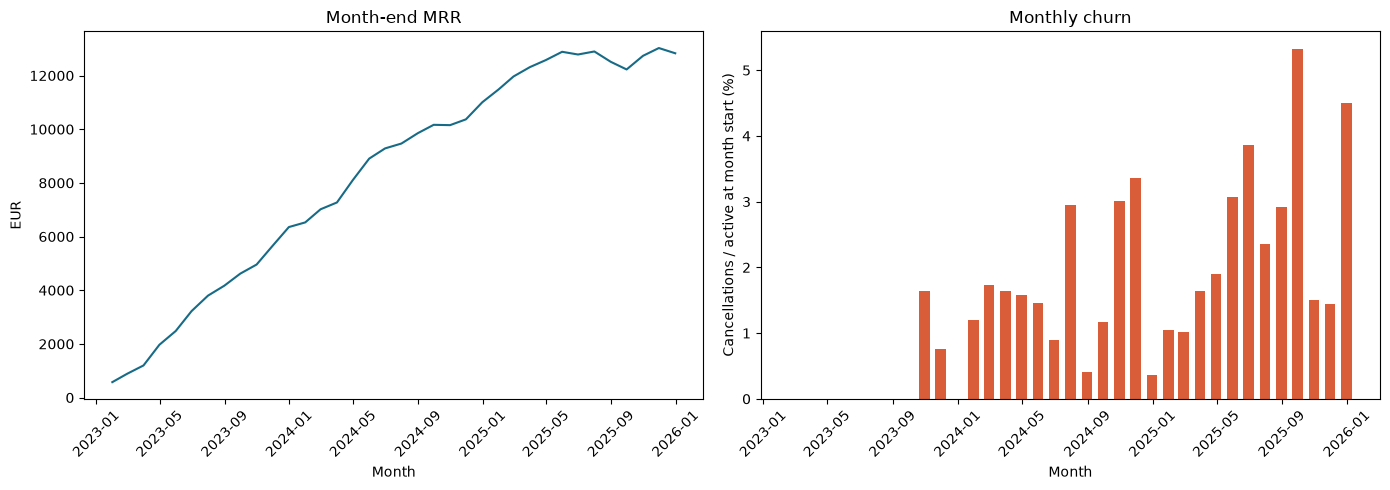

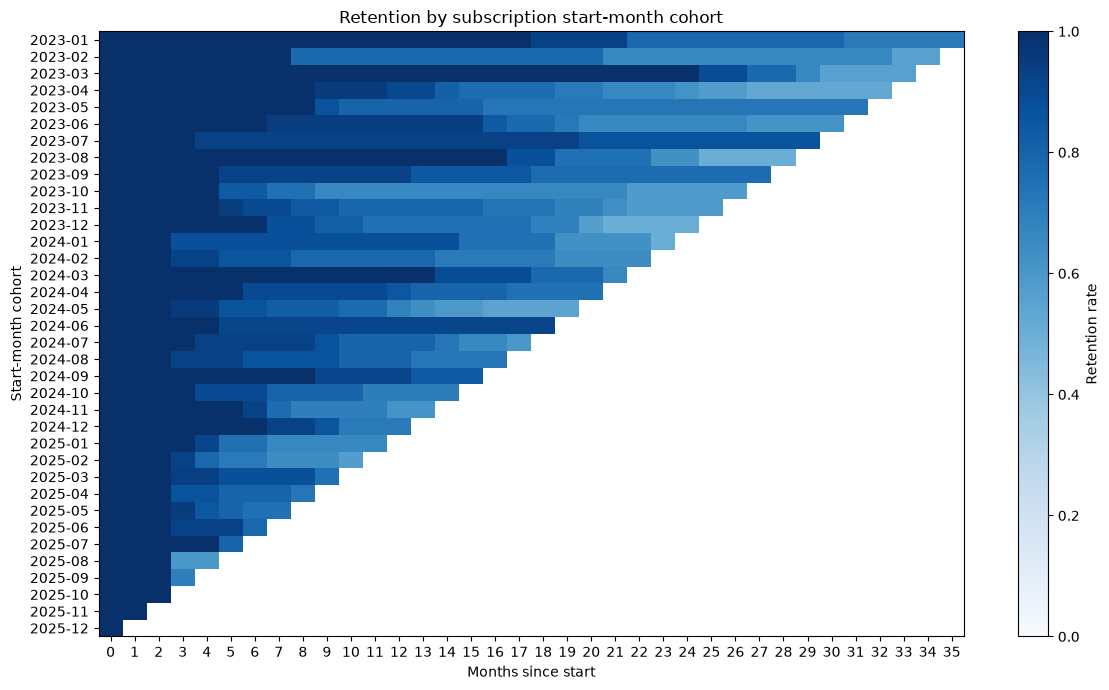

Saved charts and tables in C:\Users\zubair.hanif\Documents\Codex\2026-10-04\i\outputs\saas_retention_portfolio\outputs


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(mrr_by_month["month_end"], mrr_by_month["mrr_eur"], color="#176B87")
axes[0].set(title="Month-end MRR", xlabel="Month", ylabel="EUR")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(
    monthly_churn["month_end"],
    monthly_churn["monthly_churn_rate"] * 100,
    color="#D95D39",
    width=20,
)
axes[1].set(
    title="Monthly churn",
    xlabel="Month",
    ylabel="Cancellations / active at month start (%)",
)
axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "revenue_and_churn.png", dpi=180, bbox_inches="tight")
plt.show()

matrix = cohort_retention.pivot(
    index="cohort_month", columns="months_since_start", values="retention_rate"
)
fig, ax = plt.subplots(figsize=(12, 7))
heatmap = ax.imshow(matrix.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap="Blues")
ax.set(title="Retention by subscription start-month cohort",
       xlabel="Months since start", ylabel="Start-month cohort")
ax.set_yticks(range(len(matrix.index)))
ax.set_yticklabels(matrix.index)
ax.set_xticks(range(len(matrix.columns)))
ax.set_xticklabels(matrix.columns)
fig.colorbar(heatmap, ax=ax, label="Retention rate")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cohort_retention.png", dpi=180, bbox_inches="tight")
plt.show()

for name, table in {
    "mrr_by_month": mrr_by_month,
    "monthly_churn": monthly_churn,
    "cohort_retention": cohort_retention,
    "plan_summary": plan_summary,
    "quality_report": quality_report,
}.items():
    table.to_csv(OUTPUT_DIR / f"{name}.csv", index=False)

print(f"Saved charts and tables in {OUTPUT_DIR.resolve()}")

## Findings from the included simulated sample

- Month-end MRR increased from €576 in January 2023 to €12,830 in December 2025.
- December 2025 churn was 16 cancellations out of 356 subscriptions active at month start: 4.5%.
- Cumulative cancellations were 16/49 for Business (32.7%), 55/173 for Pro (31.8%), and 79/278 for Basic (28.4%).

These are computed from the simulated data. They do not describe a real company or prove the cause of cancellations.

## Chart previews

The README displays SVG previews generated from these tables. Run the final chart cell to also create PNGs with Matplotlib.

## Limitations

- The data is simulated.
- The plan comparison is cumulative and may reflect tenure differences.
- Recent cohorts have less follow-up time.

## Before publishing

Keep the synthetic-data limitation visible in the GitHub README and CV. Run every cell in a Python environment with the packages in requirements.txt to regenerate the PNG charts.
